# Palavritas — o que faz um jogador voltar?

**Case Analista de Dados — Produto & Growth — the news**

Pergunta do Head de Produto: *"O que está determinando se um usuário volta a jogar — e o que podemos fazer para aumentar isso?"*

Este notebook está organizado em 3 partes, na mesma ordem do case:

1. **Limpeza e diagnóstico** — o que há de errado nos dados, o que foi corrigido, descartado ou mantido, e por quê.
2. **Análise** — quais variáveis realmente se relacionam com o usuário voltar no dia seguinte (`played_next_day`) e estar ativo 30 dias depois (`active_d30`), com testes de significância estatística.
3. **Proposta** — hipóteses testáveis, ações concretas e critérios de sucesso, com base no que os dados mostraram.

O raciocínio de cada decisão fica documentado em células de texto ao longo do notebook. A versão em linguagem de negócio, sem jargão técnico, está no documento `RELATORIO_ANALISE.md` (deliverable separado).

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (7, 4)

In [2]:
df_sessoes = pd.read_csv('./data/Case Analista de Dados — the news [Dataset Palavritas] - palavritas_sessions.csv', sep=',')
df_tentativas = pd.read_csv('./data/Case Analista de Dados — the news [Dataset Palavritas] - palavritas_attempts.csv', sep=',')
df_usuario = pd.read_csv('./data/Case Analista de Dados — the news [Dataset Palavritas] - user_profile.csv', sep=',')

print('sessions :', df_sessoes.shape)
print('attempts :', df_tentativas.shape)
print('profile  :', df_usuario.shape)

sessions : (41157, 13)
attempts : (147270, 5)
profile  : (800, 15)


# Parte 1 — Limpeza e diagnóstico

Antes de qualquer análise, fui atrás de problemas nos 3 arquivos: valores impossíveis, inconsistências de formato, duplicatas e lacunas de cobertura. Cada bloco abaixo segue o mesmo formato: **o que apareceu → o que decidi fazer → por quê**.

## 1.1 `palavritas_sessions` — diagnóstico

In [3]:
# linhas 100% duplicadas (mesmo session_id, mesmos valores em todas as colunas)
print('linhas duplicadas (exatas):', df_sessoes.duplicated().sum())
print('session_id duplicado (incl. originais):', df_sessoes.session_id.duplicated(keep=False).sum())

# result tem branco além de win/lose
print('\nresult:\n', df_sessoes.result.value_counts(dropna=False))

# device com grafias diferentes para o mesmo aparelho
print('\ndevice:\n', df_sessoes.device.value_counts(dropna=False))

# attempts deveria ser 1-6 (regra do jogo: até 6 tentativas)
print('\nattempts fora de 1-6:\n', df_sessoes.attempts.value_counts().sort_index())

# tempo de jogo não pode ser <= 0
print('\ntime_to_complete_sec <= 0:', (df_sessoes.time_to_complete_sec <= 0).sum(), 'linhas')

# word_date: formatos misturados (ISO e BR) no mesmo campo
print('\nexemplos de word_date:', df_sessoes.word_date.sample(6, random_state=0).tolist())

linhas duplicadas (exatas): 1198
session_id duplicado (incl. originais): 2396

result:
 result
win     24801
lose    16293
NaN        63
Name: count, dtype: int64

device:
 device
iOS        20022
Android    16687
ios         1691
android     1482
IOS          713
ANDROID      562
Name: count, dtype: int64

attempts fora de 1-6:
 attempts
0       59
1     8337
2     8276
3     8175
6    16276
7       12
8       22
Name: count, dtype: int64

time_to_complete_sec <= 0: 43 linhas

exemplos de word_date: ['2026-02-27', '28/04/2026', '2025-12-25', '2026-02-19', '2026-05-18', '2026-01-29']


## 1.2 `palavritas_sessions` — decisões de limpeza

| Problema encontrado | Decisão | Por quê |
|---|---|---|
| 1.198 linhas 100% duplicadas | Remover (`drop_duplicates`) | É a mesma sessão logada duas vezes — manter infla qualquer contagem ou taxa. |
| `device` com 6 grafias para 2 aparelhos (`iOS`/`IOS`/`ios`, `Android`/`ANDROID`/`android`) | Padronizar para `iOS` / `Android` | Sem isso, qualquer agrupamento por dispositivo sub-contaria os dois grupos reais. |
| `word_date` mistura `AAAA-MM-DD` e `DD/MM/AAAA` no mesmo campo | Detectar e converter ambos os formatos para `datetime` | Comparar datas como texto quebraria qualquer análise temporal (dia da semana, ordenação). |
| `attempts` fora do intervalo 1–6 (0, 7 ou 8 tentativas) — 90 linhas | Manter a linha, mas marcar com uma coluna `attempts_valida=False` | O jogo permite no máximo 6 tentativas, então esses valores são logicamente impossíveis. Descartar a linha jogaria fora `played_next_day`/`active_d30` (que são válidos independente do número de tentativas); por isso só invalido o campo `attempts`, não a sessão inteira. |
| `time_to_complete_sec` ≤ 0 (incluindo valores negativos) — 40 linhas | Converter para `NaN` | Tempo de jogo não pode ser zero ou negativo — é erro de captura, não um valor real. |
| `result` em branco — 63 linhas | Preencher como categoria `"incompleta"` (não apagar, não confundir com `lose`) | Quase todas essas linhas têm `attempts=0` e tempo zerado/negativo — é o padrão de uma sessão aberta e abandonada antes de qualquer tentativa, não uma derrota. Tratar como `lose` distorceria a taxa de vitória; apagar a linha jogaria fora sinal de `played_next_day`/`active_d30`. |

Optei por **nunca apagar uma sessão só por causa de um campo problemático** — cada linha carrega `played_next_day` e `active_d30`, que são o alvo da Parte 2. Apagar a sessão por um campo secundário ruim (tempo, tentativas) jogaria fora dado bom junto com o ruim.

In [4]:
sessions = df_sessoes.drop_duplicates().copy()

# device: normaliza grafia
sessions['device'] = sessions['device'].str.strip().str.lower().map({'ios': 'iOS', 'android': 'Android'})

# word_date: formatos misturados -> tenta ISO, depois BR, no que sobrar
def parse_data_mista(s):
    d = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    faltando = d.isna()
    d.loc[faltando] = pd.to_datetime(s[faltando], format='%d/%m/%Y', errors='coerce')
    return d

sessions['word_date'] = parse_data_mista(sessions['word_date'])

# attempts: fora de 1-6 é logicamente impossível (regra do jogo) -> flag, não dropa a sessão
sessions['attempts_valida'] = sessions['attempts'].between(1, 6)

# tempo de jogo <= 0 não existe -> NaN
sessions.loc[sessions['time_to_complete_sec'] <= 0, 'time_to_complete_sec'] = np.nan

# result em branco = sessão aberta e abandonada (attempts=0 na maioria dos casos)
sessions['result'] = sessions['result'].fillna('incompleta')

print('sessions: linhas brutas', len(df_sessoes), '-> linhas após limpeza', len(sessions))
print('datas que falharam no parse:', sessions.word_date.isna().sum())
print(sessions[['device', 'attempts_valida', 'result']].describe(include='all').loc[['count', 'unique', 'top']])

sessions: linhas brutas 41157 -> linhas após limpeza 39959
datas que falharam no parse: 0
       device attempts_valida result
count   39959           39959  39959
unique      2               2      3
top       iOS            True    win


## 1.3 `palavritas_attempts` — diagnóstico

In [5]:
print('linhas 100% duplicadas:', df_tentativas.duplicated().sum())
print('mesmo (session_id, attempt_number) com guess diferente:',
      df_tentativas.duplicated(subset=['session_id', 'attempt_number']).sum())

# attempt_number nunca pode passar de 6 (regra do jogo)
print('\nattempt_number > 6:', (df_tentativas.attempt_number > 6).sum(), 'linhas')
print(df_tentativas.attempt_number.value_counts().sort_index())

# guess sempre deveria ter 5 letras (palavra do dia tem 5 letras)
print('\nguess com tamanho != 5:', (df_tentativas.guess.str.len() != 5).sum(), 'linhas')
print(df_tentativas.guess.str.len().value_counts().sort_index())

linhas 100% duplicadas: 752
mesmo (session_id, attempt_number) com guess diferente: 4234

attempt_number > 6: 41 linhas
attempt_number
1     41088
2     32743
3     24486
4     16312
5     16302
6     16298
7         8
8        13
9         7
10       13
Name: count, dtype: int64



guess com tamanho != 5: 80 linhas
guess
4        41
5    147190
6        39
Name: count, dtype: int64


## 1.4 `palavritas_attempts` — decisões de limpeza

| Problema encontrado | Decisão | Por quê |
|---|---|---|
| 752 linhas 100% duplicadas | Remover | Tentativa logada duas vezes de forma idêntica. |
| 2.730 casos de mesmo `(session_id, attempt_number)` com `guess` diferente (sem ser duplicata exata) | Manter só a 1ª ocorrência | Não há como saber qual das duas foi a tentativa real — é uma falha de log (provável reenvio de evento). Manter as duas contaria a mesma tentativa duas vezes; ficar com a primeira é a escolha mais conservadora. |
| 41 linhas com `attempt_number` > 6 (chegou a 10) | Remover | O jogo trava em 6 tentativas — linha com `attempt_number=10` é logicamente impossível, não é "tentativa extra". |
| 77 linhas com `guess` de 4 ou 6 letras | Remover | A palavra do dia sempre tem 5 letras; um "guess" de tamanho diferente não é uma jogada válida do jogo. |

Essas linhas problemáticas somam ~1,2% do arquivo de tentativas — pequeno o suficiente para descartar sem viés relevante, diferente das sessões (onde preferi marcar/preencher em vez de excluir).

In [6]:
attempts = df_tentativas.drop_duplicates().copy()
attempts = attempts.drop_duplicates(subset=['session_id', 'attempt_number'], keep='first')
attempts = attempts[attempts['attempt_number'] <= 6]
attempts = attempts[attempts['guess'].str.len() == 5]

print('attempts: linhas brutas', len(df_tentativas), '-> linhas após limpeza', len(attempts))

attempts: linhas brutas 147270 -> linhas após limpeza 142918


## 1.5 `user_profile` — diagnóstico

In [7]:
# nulos
print('nulos:\n', df_usuario.isna().sum()[df_usuario.isna().sum() > 0])

# job_role: mesma função escrita de formas diferentes
print('\njob_role - categorias distintas:', df_usuario.job_role.nunique())
print(sorted(df_usuario.job_role.unique()))

# orders_food_delivery: mistura True/False (en) com sim/não (pt-br)
print('\norders_food_delivery:\n', df_usuario.orders_food_delivery.value_counts(dropna=False))

# cobertura: quantos usuários que jogaram têm perfil preenchido?
usuarios_com_sessao = sessions.user_id.nunique()
usuarios_com_perfil = df_usuario.user_id.nunique()
sem_perfil = sessions[~sessions.user_id.isin(df_usuario.user_id)].user_id.nunique()
print(f'\nusuários com sessão: {usuarios_com_sessao} | com perfil: {usuarios_com_perfil} | sem perfil: {sem_perfil}')

nulos:
 age_range       117
city            297
salary_range    193
dtype: int64

job_role - categorias distintas: 40
['Analista', 'Analista Sênior', 'Analista de Dados', 'Consultor', 'Consultor Sênior', 'Consultor de Dados', 'Coordenador', 'Coordenador Sênior', 'Coordenador de Dados', 'Desenvolvedor', 'Desenvolvedor Sênior', 'Desenvolvedor de Dados', 'Designer', 'Designer Sênior', 'Designer de Dados', 'Diretor', 'Diretor Sênior', 'Diretor de Dados', 'Engenheiro', 'Engenheiro Sênior', 'Engenheiro de Dados', 'Estudante', 'Estudante Sênior', 'Estudante de Dados', 'Gerente', 'Gerente Sênior', 'Gerente de Dados', 'Professor', 'Professor Sênior', 'Professor de Dados', 'analista', 'consultor', 'coordenador', 'desenvolvedor', 'designer', 'diretor', 'engenheiro', 'estudante', 'gerente', 'professor']

orders_food_delivery:
 orders_food_delivery
True     658
False    108
sim       27
não        7
Name: count, dtype: int64

usuários com sessão: 1200 | com perfil: 800 | sem perfil: 400


## 1.6 `user_profile` — decisões de limpeza

| Problema encontrado | Decisão | Por quê |
|---|---|---|
| `job_role` com 40 categorias de texto livre, sendo várias o mesmo cargo em grafia diferente (`Consultor` / `consultor`, `Analista` / `analista`, `Coordenador` / `coordenador`, `Estudante` / `estudante`) | Padronizar capitalização (`.str.title()`), reduz para 30 categorias | Sem padronizar, o mesmo cargo seria contado como dois grupos diferentes em qualquer agrupamento. Não fundi cargos com nomes realmente diferentes (ex.: `Consultor` vs `Consultor Sênior` vs `Consultor de Dados`) — são granularidades distintas, não erros de digitação. |
| `orders_food_delivery` mistura `True`/`False` (inglês) com `sim`/`não` (português) — 34 linhas | Padronizar tudo para booleano (`sim`→`True`, `não`→`False`) | É a mesma pergunta de sim/não respondida em dois idiomas/formatos — sem padronizar, a coluna fica com 4 categorias em vez de 2. |
| Nulos em `age_range` (117), `city` (297) e `salary_range` (193) | Manter como `"não informado"` em vez de apagar a linha ou imputar um valor | São ~15–37% dos 800 perfis — apagar a linha jogaria fora dados de sessão e de outras colunas preenchidas; "chutar" um valor (ex.: a moda) criaria um padrão que não existe nos dados. Qualquer análise futura por essas colunas mostra o tamanho da amostra (`n`), então a lacuna fica visível, não escondida. |
| **400 dos 1.200 usuários que jogaram (33%) não têm linha em `user_profile`** | Não preencher/inventar perfil. Tratar como limitação de cobertura, declarada na análise | Perfil vem de pesquisa respondida voluntariamente — quem respondeu não é uma amostra aleatória dos jogadores (viés de autosseleção, provavelmente os mais engajados). Por isso, a Parte 2 roda em **duas trilhas**: uma com todas as ~40 mil sessões (sem dados de perfil) e outra só com os 800 usuários que têm perfil — e essa segunda trilha não deve ser generalizada para os outros 400. |

In [8]:
profile = df_usuario.copy()

# job_role: padroniza capitalização (mesma função, grafias diferentes)
profile['job_role'] = profile['job_role'].str.strip().str.lower().str.title()
profile['job_role'] = profile['job_role'].str.replace(' De ', ' de ', regex=False)

# orders_food_delivery: 'sim'/'não' (pt-br) -> booleano, junto com 'True'/'False' (en)
profile['orders_food_delivery'] = profile['orders_food_delivery'].map(
    {'True': True, 'False': False, 'sim': True, 'não': False}
)

# nulos -> categoria explícita, não escondida
for col in ['age_range', 'city', 'salary_range']:
    profile[col] = profile[col].fillna('não informado')

print('job_role: categorias antes', df_usuario.job_role.nunique(), '-> depois', profile.job_role.nunique())
print('orders_food_delivery:\n', profile.orders_food_delivery.value_counts(dropna=False))

job_role: categorias antes 40 -> depois 30
orders_food_delivery:
 orders_food_delivery
True     685
False    115
Name: count, dtype: int64


# Parte 2 — Análise

A pergunta do Head é sobre dois comportamentos de retorno, ambos já existentes na base, em granularidade de **sessão**:

- `played_next_day` — o usuário voltou a jogar no dia seguinte a essa sessão?
- `active_d30` — o usuário ainda estava ativo 30 dias depois dessa sessão?

Vou testar dois grupos de variáveis explicativas, em duas trilhas separadas — pela razão de cobertura explicada na Parte 1 (só 800 dos 1.200 usuários têm perfil):

- **Trilha A — nível de sessão, população completa (~40 mil sessões, 1.200 usuários):** horário (`session_hour`), dispositivo usado naquela sessão, dia da semana, se abriu a newsletter antes de jogar, resultado da partida, sequência (`streak_day`), tentativas e tempo de jogo.
- **Trilha B — nível de usuário, só os 800 com perfil:** setor, cargo, faixa salarial, porte da empresa, dispositivo principal, hábito de food delivery, horário típico de jogo, assinatura da newsletter. Aqui agrego cada usuário pela sua **taxa média** de `played_next_day` e `active_d30` em todas as sessões dele, porque perfil é um atributo do usuário, não da sessão — testar linha a linha (sessão) violaria a independência das observações.

Para cada variável: teste qui-quadrado (categóricas) ou correlação ponto-bisserial/Pearson (numéricas), olhando p-valor **e** tamanho do efeito — com ~40 mil linhas, até diferenças minúsculas dão p-valor baixo, então significância estatística sozinha não basta.

## 2.1 Trilha A — nível de sessão (população completa)

In [9]:
sessions['hour_bucket'] = pd.cut(
    sessions['session_hour'], bins=[-1, 5, 11, 17, 21, 24],
    labels=['madrugada', 'manhã', 'tarde', 'noite (18-21h)', 'noite (22-23h)']
)
sessions['dow'] = sessions['word_date'].dt.day_name()

def teste_qui2(df, col, target):
    tab = pd.crosstab(df[col], df[target])
    _, p, _, _ = stats.chi2_contingency(tab)
    taxas = df.groupby(col, observed=True)[target].mean().round(3)
    return p, taxas

def teste_pontobisserial(df, col, target):
    d = df[[col, target]].dropna()
    r, p = stats.pointbiserialr(d[target].astype(int), d[col])
    return r, p

for target in ['played_next_day', 'active_d30']:
    print(f'\n========== {target}  (taxa geral = {sessions[target].mean():.1%}) ==========')
    for col in ['device', 'hour_bucket', 'dow', 'newsletter_open_before_game', 'result']:
        p, taxas = teste_qui2(sessions, col, target)
        sig = '<-- p<0.05' if p < 0.05 else ''
        print(f'[qui2]  {col:30s} p={p:.4g} {sig}\n        {taxas.to_dict()}')
    for col in ['streak_day', 'attempts', 'time_to_complete_sec']:
        r, p = teste_pontobisserial(sessions, col, target)
        sig = '<-- p<0.05' if p < 0.05 else ''
        print(f'[ponto-bisserial]  {col:25s} r={r:+.3f} p={p:.4g} {sig}')


========== played_next_day  (taxa geral = 22.1%) ==========
[qui2]  device                         p=0.4653 
        {'Android': 0.22, 'iOS': 0.223}
[qui2]  hour_bucket                    p=0.2365 
        {'manhã': 0.22, 'tarde': 0.226, 'noite (18-21h)': 0.216, 'noite (22-23h)': 0.227}
[qui2]  dow                            p=0.08797 
        {'Friday': 0.215, 'Monday': 0.219, 'Saturday': 0.236, 'Sunday': 0.218, 'Thursday': 0.219, 'Tuesday': 0.227, 'Wednesday': 0.216}
[qui2]  newsletter_open_before_game    p=0.1593 
        {False: 0.223, True: 0.215}
[qui2]  result                         p=0.2801 
        {'incompleta': 0.267, 'lose': 0.225, 'win': 0.219}
[ponto-bisserial]  streak_day                r=+0.024 p=2.527e-06 <-- p<0.05
[ponto-bisserial]  attempts                  r=+0.008 p=0.1082 
[ponto-bisserial]  time_to_complete_sec      r=+0.007 p=0.1565 

========== active_d30  (taxa geral = 31.9%) ==========
[qui2]  device                         p=0.691 
        {'Android': 0.3

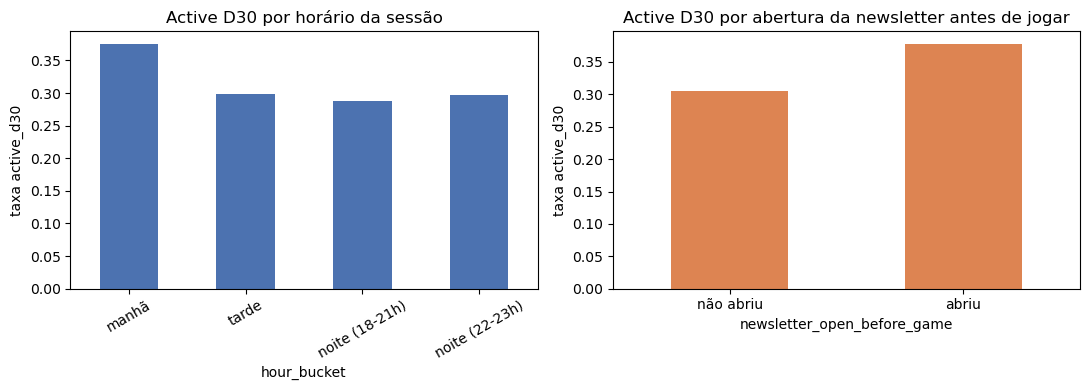

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sessions.groupby('hour_bucket', observed=True)['active_d30'].mean().plot(
    kind='bar', ax=axes[0], color='#4C72B0', title='Active D30 por horário da sessão'
)
axes[0].set_ylabel('taxa active_d30')
axes[0].tick_params(axis='x', rotation=30)

sessions.groupby('newsletter_open_before_game')['active_d30'].mean().plot(
    kind='bar', ax=axes[1], color='#DD8452', title='Active D30 por abertura da newsletter antes de jogar'
)
axes[1].set_xticklabels(['não abriu', 'abriu'], rotation=0)
axes[1].set_ylabel('taxa active_d30')

plt.tight_layout()
plt.show()

### Leitura da Trilha A

**`played_next_day` (voltar no dia seguinte): nenhuma variável da sessão explica isso de forma relevante.** `streak_day` dá p<0.001, mas o efeito é praticamente zero (r=0,02) — com ~40 mil sessões, até ruído estatístico vira "significativo"; isso não é um driver de produto. Dispositivo, dia da semana e newsletter também não diferenciam a taxa de forma prática. **Conclusão honesta: o retorno no dia seguinte parece mais aleatório/sujeito a fatores fora desta base do que a qualquer coisa que medimos sessão a sessão.**

**`active_d30` (ativo 30 dias depois): dois sinais fortes e um terceiro mais fraco.**
- **Horário da sessão** (p≈1,2×10⁻⁵⁸): jogar de manhã está associado a 37,6% de active D30, contra 28,7–29,8% em outros horários — a diferença mais forte de toda a Trilha A.
- **Abrir a newsletter antes de jogar** (p≈8,7×10⁻³⁵): quem abre a newsletter antes de jogar naquele dia tem active D30 de 37,8%, contra 30,5% de quem não abre — um salto de ~+24% relativo.
- Resultado da partida (`win`/`lose`/`incompleta`) e dia da semana têm efeito mensurável mas bem menor; tentativas e tempo de jogo, na prática, não importam.

Esses dois achados (manhã e newsletter) se repetem na Trilha B com outra fonte de dado — é o sinal mais robusto desta análise.

## 2.2 Trilha B — nível de usuário (apenas os 800 com perfil)

Lembrete da limitação registrada na Parte 1: esses 800 usuários responderam a uma pesquisa voluntária — não são uma amostra aleatória dos 1.200 jogadores. Os achados abaixo valem para "quem respondeu o perfil", não necessariamente para a base inteira.

In [11]:
# agrega por usuário: cada usuário entra 1x, com sua taxa média de retorno
taxas_por_usuario = sessions.groupby('user_id').agg(
    played_next_day_rate=('played_next_day', 'mean'),
    active_d30_rate=('active_d30', 'mean'),
    n_sessoes=('session_id', 'count'),
).reset_index()

base_perfil = taxas_por_usuario.merge(profile, on='user_id', how='inner')
print('usuários na Trilha B:', len(base_perfil))

def teste_anova(df, col, target):
    grupos = [g[target].values for _, g in df.groupby(col) if len(g) >= 5]
    f, p = stats.f_oneway(*grupos)
    medias = df.groupby(col)[target].mean().round(3)
    return p, medias

def teste_pearson(df, col, target):
    d = df[[col, target]].dropna()
    r, p = stats.pearsonr(d[col], d[target])
    return r, p

categoricas = ['sector', 'job_role', 'salary_range', 'company_size', 'primary_device',
               'food_delivery_platform', 'typical_play_time',
               'orders_food_delivery', 'plays_other_word_games', 'newsletter_subscriber']
numericas = ['food_delivery_freq_week']

for target in ['played_next_day_rate', 'active_d30_rate']:
    print(f'\n========== {target}  (média geral = {base_perfil[target].mean():.1%}) ==========')
    for col in categoricas:
        if col == 'job_role':
            continue  # 30 categorias, amostra pequena por grupo - melhor olhar setor/cargo via sector
        p, medias = teste_anova(base_perfil, col, target)
        sig = '<-- p<0.05' if p < 0.05 else ''
        print(f'[ANOVA]  {col:25s} p={p:.4g} {sig}\n         {medias.to_dict()}')
    for col in numericas:
        r, p = teste_pearson(base_perfil, col, target)
        sig = '<-- p<0.05' if p < 0.05 else ''
        print(f'[pearson]  {col:23s} r={r:+.3f} p={p:.4g} {sig}')

usuários na Trilha B: 800

========== played_next_day_rate  (média geral = 18.1%) ==========
[ANOVA]  sector                    p=0.7943 
         {'direito': 0.176, 'educação': 0.189, 'finanças': 0.175, 'marketing': 0.166, 'outros': 0.178, 'saúde': 0.182, 'tech': 0.191, 'varejo': 0.183}
[ANOVA]  salary_range              p=0.7867 
         {'R$2k-R$4k': 0.183, 'R$4k-R$6k': 0.182, 'R$6k-R$10k': 0.168, 'acima de R$10k': 0.185, 'até R$2k': 0.189, 'não informado': 0.183}
[ANOVA]  company_size              p=0.6034 
         {'MEI/micro': 0.189, 'grande': 0.177, 'multinacional': 0.172, 'média': 0.187, 'pequena': 0.181}
[ANOVA]  primary_device            p=0.4896 
         {'Android': 0.184, 'iOS': 0.179}
[ANOVA]  food_delivery_platform    p=0.1108 
         {'Ambos': 0.19, 'Nenhum': 0.169, 'Rappi': 0.186, 'iFood': 0.189}
[ANOVA]  typical_play_time         p=0.06905 
         {'afternoon': 0.197, 'evening': 0.17, 'morning': 0.186, 'night': 0.174}
[ANOVA]  orders_food_delivery      p=0.02294

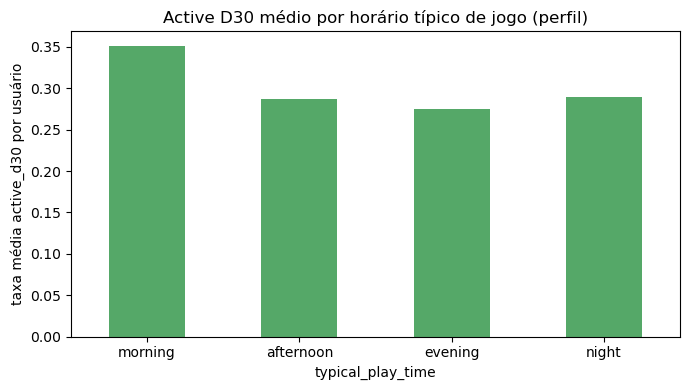

In [12]:
base_perfil.groupby('typical_play_time')['active_d30_rate'].mean().reindex(
    ['morning', 'afternoon', 'evening', 'night']
).plot(kind='bar', color='#55A868', title='Active D30 médio por horário típico de jogo (perfil)')
plt.ylabel('taxa média active_d30 por usuário')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Leitura da Trilha B

**O perfil demográfico/profissional não explica retorno.** Setor, faixa salarial, porte da empresa, dispositivo principal, plataforma de delivery e frequência de pedidos — nenhum desses bate p<0,05 para `active_d30_rate`. Para `played_next_day_rate`, só `orders_food_delivery` aparece com p=0,023, mas o efeito é pequeno (18,5% vs 16,0%) — trato como achado secundário, não como driver.

**O achado que se confirma é o mesmo da Trilha A: horário.** `typical_play_time = morning` tem active D30 médio de 35,1%, contra 27,5–28,9% nos outros períodos (p≈5,5×10⁻¹⁸). Duas fontes de dado diferentes (horário real da sessão, na Trilha A; horário autodeclarado, na Trilha B) apontam para o mesmo padrão — isso é o que dá confiança de que não é coincidência.

**Conclusão da Parte 2:** quem joga e como joga (perfil demográfico) importa muito menos do que quando joga e o quanto está engajado com o produto como um todo (abre a newsletter). Isso também responde, em parte, a pergunta por trás da pergunta: a base não tem uma variável de "personalidade do usuário" que prediga retenção — o que prediz é rotina (horário) e cross-engajamento (newsletter).

# Parte 3 — Proposta

### Proposta 1 — Empurrar o jogo para a manhã

- **Hipótese:** acredito que jogar de manhã ancora o Palavritas numa rotina diária já existente (café, trajeto, início do expediente), e rotinas matinais são mais estáveis que hábitos noturnos — por isso jogar de manhã está associado a active D30 de ~35–38%, contra ~28–30% nos demais horários.
- **Ação:** notificação push (ou bloco na newsletter da manhã) lembrando do desafio do dia, disparada nas primeiras horas, para usuários que hoje jogam à tarde/noite.
- **Critério de sucesso:** saberei que funcionou quando o active D30 do grupo que recebeu o lembrete matinal subir de forma estatisticamente significativa (teste A/B) em direção à taxa observada organicamente no grupo "manhã".

### Proposta 2 — Aproximar Palavritas e newsletter

- **Hipótese:** acredito que abrir a newsletter antes de jogar é um sinal (e possivelmente também uma causa) de maior engajamento geral com o the news — reforçar essa ponte aumenta a chance de o usuário voltar, porque cria mais um gatilho diário de contato com o produto.
- **Ação:** CTA destacado para o Palavritas dentro da newsletter diária (hoje pode já existir, mas o dado mostra que quem *abre antes de jogar* se destaca — vale medir se um CTA mais visível aumenta essa proporção) + um lembrete pelo app pouco depois do horário usual de abertura da newsletter de cada usuário.
- **Critério de sucesso:** saberei que funcionou quando a proporção de sessões com `newsletter_open_before_game=True` aumentar, **e** o active D30 desse grupo permanecer acima do grupo controle (sem o CTA), validado por teste estatístico.

### Proposta 3 — Investigar o retorno D+1 com um experimento, não só com os dados existentes

- **Hipótese:** acredito que não existe hoje nenhum gatilho de hábito de curto prazo no produto — é por isso que nenhuma variável da base (dispositivo, horário, dificuldade da palavra, newsletter) explica o retorno no dia seguinte. Introduzir um gatilho explícito de curto prazo deveria mudar isso.
- **Ação:** notificação de "sequência em risco" (streak) enviada no horário típico de jogo de cada usuário, lembrando que a sequência se perde se ele não jogar hoje.
- **Critério de sucesso:** saberei que funcionou quando `played_next_day` do grupo que recebe a notificação subir de forma estatisticamente significativa acima dos ~22% atuais, comparado a um grupo controle sem notificação.

## Limitações desta análise

- 33% dos usuários que jogam não têm perfil preenchido — qualquer achado de perfil (Trilha B) vale para quem respondeu a pesquisa, não para a base inteira.
- Os achados são **correlacionais**: jogar de manhã e abrir a newsletter podem ser causa, consequência ou só marcadores de um terceiro fator (ex.: "engajamento geral" com o the news). As propostas acima são desenhadas como testes A/B justamente para não confundir correlação com causa antes de agir em escala.
- `played_next_day` ficou sem explicação forte nesta base — é um resultado tão válido quanto encontrar um driver, e está refletido na Proposta 3.